Analysis of the different model used

LINEAR REGRESSION (model 1):

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0,str(project_root))
print(sys.path[:3])


['/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction', '/opt/anaconda3/envs/air-quality/lib/python312.zip', '/opt/anaconda3/envs/air-quality/lib/python3.12']


In [3]:
import src

print(src)
print(src.__file__)

<module 'src' from '/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction/src/__init__.py'>
/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction/src/__init__.py


In [4]:
from src.load_data import load_data
from src.preprocessing import X_train, X_validation, X_test, y_train, y_validation, y_test
from models.linear_regression import train_model, evaluate_model
import matplotlib.pyplot as plt
linear_model = train_model(X_train, y_train)
#to evaluate the model we will use 3 metrics: MAE, RMSE, and R2
y_validation_pred, mae, rmse, r2 = evaluate_model(linear_model, X_validation, y_validation)


In [5]:
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)
print(
    "Actual PM2.5 range:",
    y_validation.min(),
    "→",
    y_validation.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred.min(),
    "→",
    y_validation_pred.max()
)

Validation MAE: 41.09320701468777
Validation RMSE: 56.56348111665171
Validation R²: 0.35146995936551784
Actual PM2.5 range: 3.0 → 999.0
Predicted PM2.5 range: -110.06736543460806 → 250.39355571771762


we can see that linear regression isn't able to represent extreme pollution values. Also it diplays values negative which has no physical meaning.

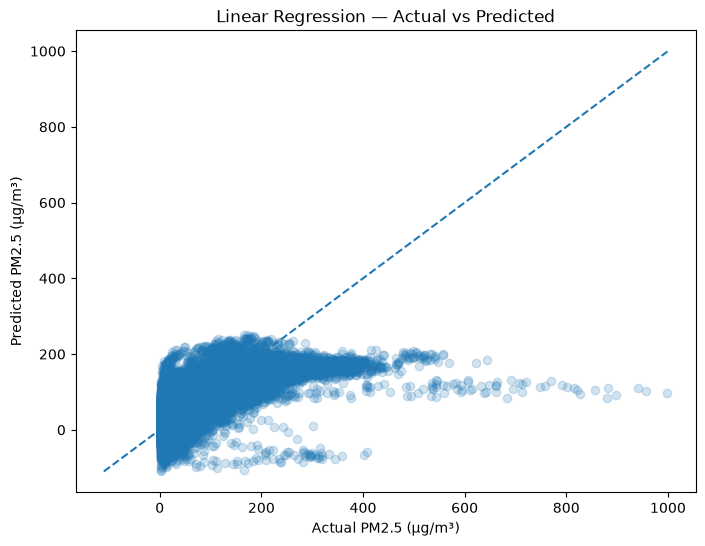

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    y_validation_pred,
    alpha=0.2
)

min_value = min(
    y_validation.min(),
    y_validation_pred.min()
)

max_value = max(
    y_validation.max(),
    y_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

LINEAR REGRESSION (model 2)

In [7]:
from src.preprocessing import X_train_pollution, X_validation_pollution, X_test_pollution, y_train_pollution, y_validation_pollution, y_test_pollution
linear_model_pollution = train_model(X_train_pollution, y_train_pollution)
y_validation_pollution_pred, mae_pollution, rmse_pollution, r2_pollution = evaluate_model(linear_model_pollution, X_validation_pollution, y_validation_pollution)

In [8]:
print("Validation MAE (Pollution):", mae_pollution)
print("Validation RMSE (Pollution):", rmse_pollution)
print("Validation R² (Pollution):", r2_pollution)
print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)
print(
    "Predicted PM2.5 range:",
    y_validation_pollution_pred.min(),
    "→",
    y_validation_pollution_pred.max()
)

Validation MAE (Pollution): 18.451862670719148
Validation RMSE (Pollution): 27.84380334172877
Validation R² (Pollution): 0.8388459962774704
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: -54.54330427706759 → 542.5041246882179


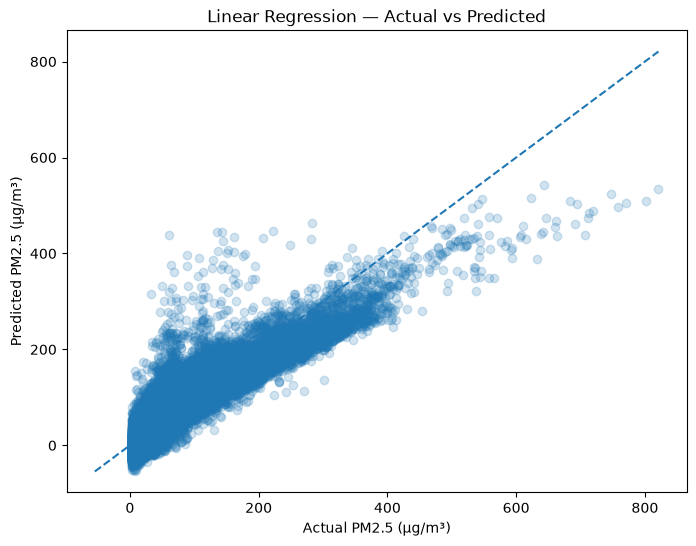

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation_pollution,
    y_validation_pollution_pred,
    alpha=0.2
)

min_value = min(
    y_validation_pollution.min(),
    y_validation_pollution_pred.min()
)

max_value = max(
    y_validation_pollution.max(),
    y_validation_pollution_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

Controlled comparison of the 2 model on the same restrictive data set (the one of model 2)

In [12]:
from src.preprocessing import X_train_common, X_validation_common, y_train_common, y_validation_common, X_train_common_pollution, X_validation_common_pollution, y_train_common_pollution, y_validation_common_pollution
linear_weather_common = train_model(X_train_common,y_train_common)
y_weather_validation,mae_weather_common,rmse_weather_common,r2_weather_common = evaluate_model(linear_weather_common,X_validation_common,y_validation_common)

In [13]:
print("Weather-only model:")
print("MAE:", mae_weather_common)
print("RMSE:", rmse_weather_common)
print("R²:", r2_weather_common)
print((
    "Predicted PM2.5 range:",
    y_weather_validation.min(),
    "→",
    y_weather_validation.max()
))

Weather-only model:
MAE: 40.67222007775052
RMSE: 54.92028957203642
R²: 0.37302587063127823
('Predicted PM2.5 range:', np.float64(-108.89566815830335), '→', np.float64(248.4766189265613))


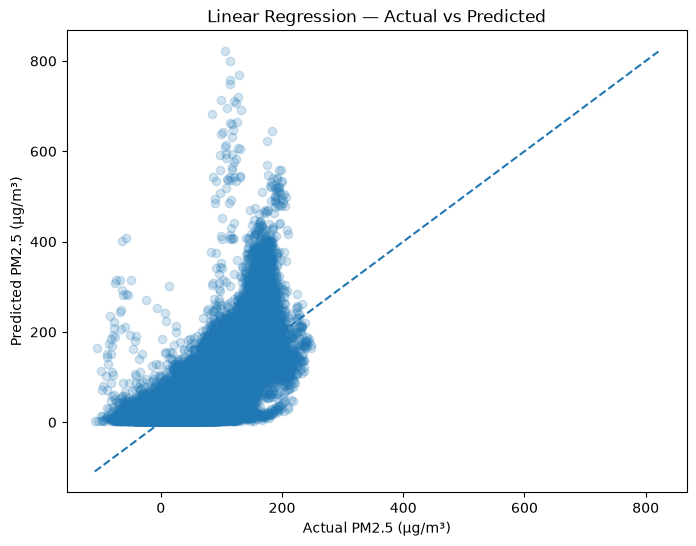

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_weather_validation,
    y_validation_common,
    alpha=0.2
)

min_value = min(
    y_weather_validation.min(),
    y_validation_common.min()
)

max_value = max(
    y_weather_validation.max(),
    y_validation_common.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

In [17]:
linear_pollution_model = train_model(X_train_common_pollution,y_train_common_pollution)
y_pollution_validation_pred,mae_pollution_common,rmse_pollution_common,r2_pollution_common = evaluate_model(linear_pollution_model,X_validation_common_pollution,y_validation_common_pollution)

In [18]:
print("Weather-pollution model:")
print("MAE:", mae_pollution_common)
print("RMSE:", rmse_pollution_common)
print("R²:", r2_pollution_common)
print((
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
))

Weather-pollution model:
MAE: 18.451862670719148
RMSE: 27.84380334172877
R²: 0.8388459962774704
('Predicted PM2.5 range:', np.float64(-54.54330427706759), '→', np.float64(542.5041246882179))


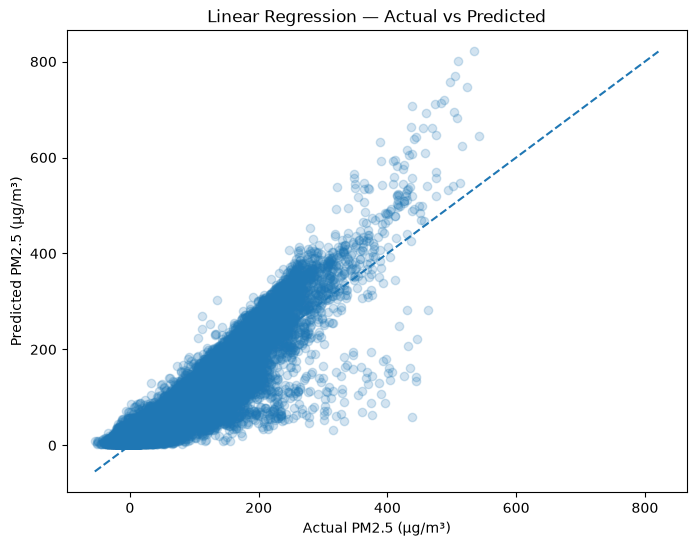

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_common_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_common_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_common_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

Improvement thanks to the pollution data:

In [20]:
rmse_improvement = (
    (rmse_weather_common - rmse_pollution_common)
    / rmse_weather_common
    * 100
)

mae_improvement = (
    (mae_weather_common - mae_pollution_common)
    / mae_weather_common
    * 100
)

print("RMSE improvement:", rmse_improvement, "%")
print("MAE improvement:", mae_improvement, "%")
print(
    "R² improvement:",
    r2_pollution_common - r2_weather_common
)

RMSE improvement: 49.30142656074795 %
MAE improvement: 54.63276252084128 %
R² improvement: 0.46582012564619213


We can see that with the same dataset, the model with pollution data has superior performances.

RANDOM FOREST

for model 1:

In [21]:
from models.random_forest import train_model, evaluate_model
from src.load_data import load_data
from src.preprocessing import X_train, X_validation, X_test, y_train, y_validation, y_test
import matplotlib.pyplot as plt
random_forest = train_model(X_train,y_train)
y_validation_pred, mae, rmse, r2 = evaluate_model(random_forest,X_validation,y_validation)


In [22]:
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)
print(
    "Actual PM2.5 range:",
    y_validation.min(),
    "→",
    y_validation.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred.min(),
    "→",
    y_validation_pred.max()
)

Validation MAE: 33.504330410444865
Validation RMSE: 53.37729776001715
Validation R²: 0.42247471101486056
Actual PM2.5 range: 3.0 → 999.0
Predicted PM2.5 range: 5.645630624388797 → 394.4389887269679


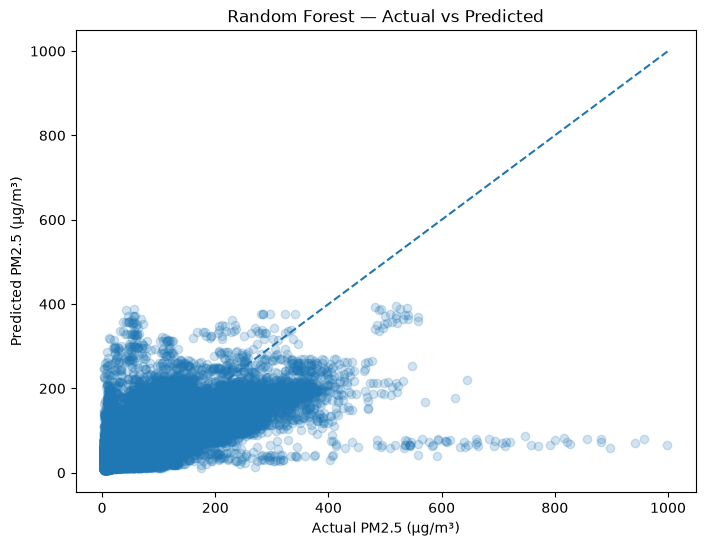

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    y_validation_pred,
    alpha=0.2
)

min_value = min(
    y_validation.min(),
    y_validation_pred.min()
)

max_value = max(
    y_validation.max(),
    y_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Random Forest — Actual vs Predicted")
plt.show()

We can see that random forest improved the prediction but much less than expected. Compared to the model 1 of linear regression, we have 18.5% of improvement for mae, 5.6% for rmse and 0.071 for R2.
Also we can observe the fact that random forest isn't predicting negative values, and can reach higher values (394 vs 250 for the linear model 1)

Model 2:

In [24]:
from src.preprocessing import X_train_pollution, X_validation_pollution, X_test_pollution, y_train_pollution, y_validation_pollution, y_test_pollution
random_forest_pollution = train_model(X_train_pollution,y_train_pollution)
y_pollution_validation_pred, mae_pollution, rmse_pollution, r2_pollution = evaluate_model(random_forest_pollution,X_validation_pollution, y_validation_pollution)

In [25]:
print("Validation MAE:", mae_pollution)
print("Validation RMSE:", rmse_pollution)
print("Validation R²:", r2_pollution)
print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)

print(
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
)

Validation MAE: 12.897036130506148
Validation RMSE: 21.803540867709792
Validation R²: 0.9011815493030064
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: 4.075182179363492 → 661.304379797705


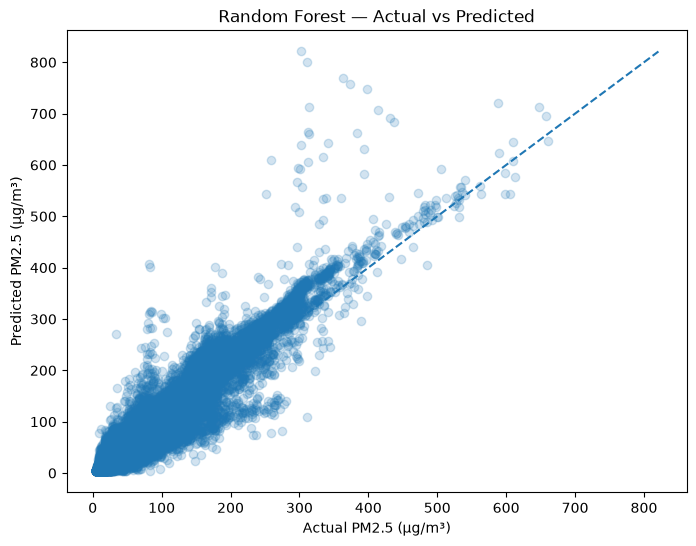

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Random Forest — Actual vs Predicted")
plt.show()

The model 2 had really good results. Random forest improved the pollution model by the following: 
- -30% mae
- -21.7% rmse
- +0.62 for R2

Controlled comparison of the 2 model on the same restrictive data set (the one of model 2):

model 1:

In [27]:
from src.preprocessing import X_train_common, X_validation_common, y_train_common, y_validation_common, X_train_common_pollution, X_validation_common_pollution, y_train_common_pollution, y_validation_common_pollution
random_forest_weather_common = train_model(X_train_common,y_train_common)
y_weather_validation,mae_weather_common,rmse_weather_common,r2_weather_common = evaluate_model(random_forest_weather_common,X_validation_common,y_validation_common)

In [28]:
print("Weather-only model:")
print("MAE:", mae_weather_common)
print("RMSE:", rmse_weather_common)
print("R²:", r2_weather_common)
print((
    "Predicted PM2.5 range:",
    y_weather_validation.min(),
    "→",
    y_weather_validation.max()
))

Weather-only model:
MAE: 33.511139314601124
RMSE: 51.83768799275582
R²: 0.44143305552775924
('Predicted PM2.5 range:', np.float64(5.203085818500084), '→', np.float64(365.99405047268357))


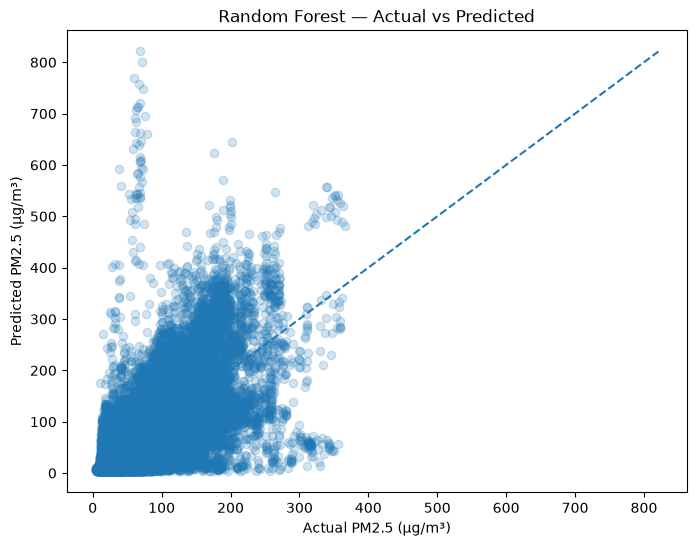

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_weather_validation,
    y_validation_common,
    alpha=0.2
)

min_value = min(
    y_weather_validation.min(),
    y_validation_common.min()
)

max_value = max(
    y_weather_validation.max(),
    y_validation_common.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Random Forest — Actual vs Predicted")
plt.show()

model 2:

In [30]:
random_forest_pollution_common = train_model(X_train_common_pollution,y_train_common_pollution)
y_pollution_validation,mae_pollution_common,rmse_pollution_common,r2_pollution_common = evaluate_model(random_forest_pollution_common,X_validation_common_pollution,y_validation_common_pollution)

In [31]:
print("Weather-pollution model:")
print("MAE:", mae_pollution_common)
print("RMSE:", rmse_pollution_common)
print("R²:", r2_pollution_common)
print((
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
))

Weather-pollution model:
MAE: 12.897036130506148
RMSE: 21.803540867709792
R²: 0.9011815493030064
('Predicted PM2.5 range:', np.float64(4.075182179363492), '→', np.float64(661.304379797705))


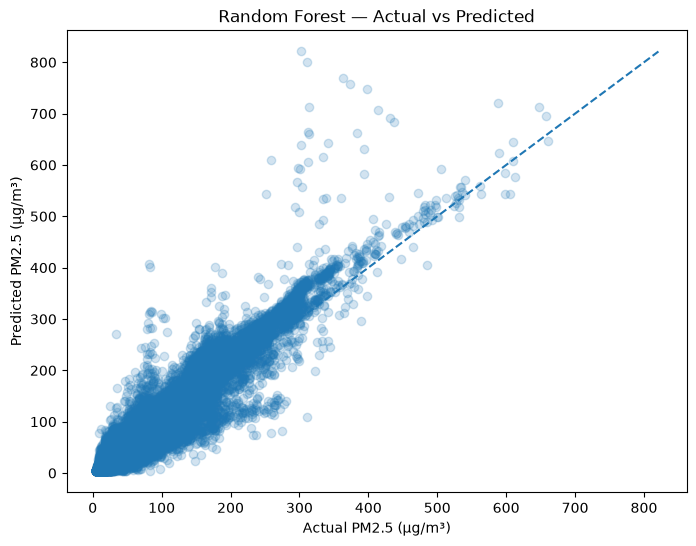

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_common_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_common_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_common_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Random Forest — Actual vs Predicted")
plt.show()

Improvements thanks to the pollution features:

In [33]:
rmse_improvement = (
    (rmse_weather_common - rmse_pollution_common)
    / rmse_weather_common
    * 100
)

mae_improvement = (
    (mae_weather_common - mae_pollution_common)
    / mae_weather_common
    * 100
)

print("RMSE improvement:", rmse_improvement, "%")
print("MAE improvement:", mae_improvement, "%")
print(
    "R² improvement:",
    r2_pollution_common - r2_weather_common
)

RMSE improvement: 57.93882460429798 %
MAE improvement: 61.51418186821602 %
R² improvement: 0.4597484937752472


XGBOOST

model 1:

In [34]:
from src.load_data import load_data
from src.preprocessing import X_train, X_validation, X_test, y_train, y_validation, y_test
from models.xgboost import train_model, evaluate_model
xgboost = train_model(X_train,y_train)
y_validation_pred,mae, rmse, r2 = evaluate_model(xgboost,X_validation,y_validation)


In [35]:
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)
print(
    "Actual PM2.5 range:",
    y_validation.min(),
    "→",
    y_validation.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred.min(),
    "→",
    y_validation_pred.max()
)

Validation MAE: 33.08858951470117
Validation RMSE: 51.56329810976008
Validation R²: 0.4610614931939885
Actual PM2.5 range: 3.0 → 999.0
Predicted PM2.5 range: -22.057192 → 317.987


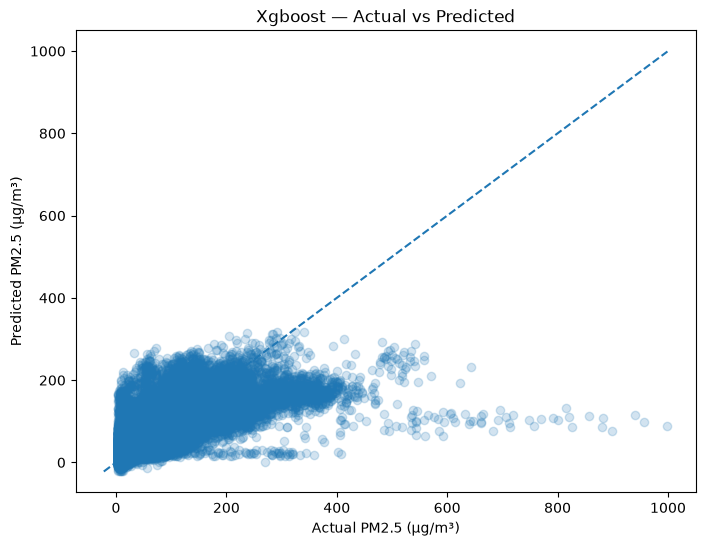

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    y_validation_pred,
    alpha=0.2
)

min_value = min(
    y_validation.min(),
    y_validation_pred.min()
)

max_value = max(
    y_validation.max(),
    y_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Xgboost — Actual vs Predicted")
plt.show()

model 2:

In [40]:
from src.preprocessing import X_train_pollution, X_validation_pollution, X_test_pollution, y_train_pollution, y_validation_pollution, y_test_pollution
xgboost_pollution = train_model(X_train_pollution,y_train_pollution)
y_pollution_validation_pred, mae_pollution, rmse_pollution, r2_pollution = evaluate_model(xgboost_pollution,X_validation_pollution, y_validation_pollution)

In [41]:
print("Validation MAE:", mae_pollution)
print("Validation RMSE:", rmse_pollution)
print("Validation R²:", r2_pollution)
print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)

print(
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
)

Validation MAE: 12.242965307540166
Validation RMSE: 21.073039031646722
Validation R²: 0.9076922155379088
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: -0.8002519 → 552.11005


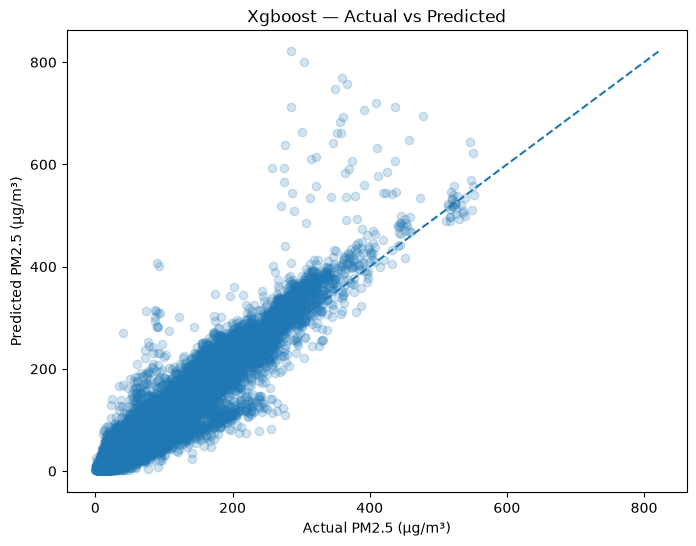

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Xgboost — Actual vs Predicted")
plt.show()

Xgboost had better performances than random forest on his dataset. 
The rmse decreased by 3.35%, the mae by 5.11% and the R2 increased by 0.0065. However we have diminishing returns showing us that Random Forest was already capturing most of the nonlinear structure available in these features. We also now have negative prediction which is physically impossible. We also have lower upper bound for the predictions compared to Random Forest.

FEATURE IMPORTANCE SECTION

We now saw that Xgboost + pollution & weather features is the best model so far. We will perform a feature importance analysis to understand which feature is driving the alpha.

FINE TUNE SECTION

 We will now perform fine tuning with respect to the validation dataset. 